# Retail_Inventory_Intelligence


In [1]:
# import All important Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# load nad read all CSV files
import glob
path = r"C:\Users\abcom\OneDrive\Documents\All_project\1._Top-3\Retail Inventory IntelligenceSystem\Raw Data"

files = glob.glob(path + r"\*.csv")

dfs = [pd.read_csv(file) for file in files]

print(len(dfs))


6


### Data Inspection

In [3]:
# Data Inspection
dfs[5].head(5)
dfs[0].tail(5)
dfs[5].shape
dfs[0].columns
dfs[0].info
dfs[0].describe()

,customer_id,age
count,5000.000000,5000.000000
mean,2500.500000,31.097800
std,1443.520003,10.746689
min,1.000000,18.000000
25%,1250.750000,20.000000
50%,2500.500000,30.000000
75%,3750.250000,35.000000
max,5000.000000,60.000000


In [4]:
# asine a varible or  all orignalfilees 
customers = dfs[0]
inventory = dfs[1]
promotions = dfs[3]
products = dfs[2]
sales = dfs[4]
stores = dfs[5]

### Data Quality Assessment

In [5]:
# Data Quality Assessment
dfs[4].isnull().sum()

#customer_id column contains 159,821 missing values.
# fill the blank cus value with 0 

dfs[4]['customer_id'] = dfs[4]['customer_id'].fillna(0)
dfs[4].isnull().sum()

#  Duplicate Records
dfs[4].duplicated().sum()

# handling Duplicate values
dfs[4].duplicated(subset=['sale_date','store_id','product_id','customer_id']).sum()
dfs[4] = dfs[4].drop_duplicates()

dfs[4].duplicated().sum()

#  Data Types

inventory['last_restock_date'] = pd.to_datetime(inventory['last_restock_date'])
inventory['inventory_date'] = pd.to_datetime(inventory['inventory_date'])

promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

sales['sale_date'] = pd.to_datetime(sales['sale_date'])

stores['opening_date'] = pd.to_datetime(stores['opening_date'])

customers['registration_date'] = pd.to_datetime(customers['registration_date'])

#  Handle Missing Values  AND Unique Values Analysis
sales.isnull().sum()



sale_date              0
store_id               0
product_id             0
customer_id            0
quantity_sold          0
unit_price             0
sales_amount           0
sales_channel          0
discount_percentage    0
dtype: int64

In [6]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              5000 non-null   int64         
 1   age                      5000 non-null   int64         
 2   gender                   5000 non-null   object        
 3   city                     5000 non-null   object        
 4   loyalty_segment          5000 non-null   object        
 5   preferred_sales_channel  5000 non-null   object        
 6   registration_date        5000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 273.6+ KB


### Referential Integrity Validation

In [7]:
# Foreign key check
sales[~ sales['product_id'].isin(products['product_id'])]

sales[~sales['store_id'].isin(stores['store_id'])]

,sale_date,store_id,product_id,customer_id,quantity_sold,unit_price,sales_amount,sales_channel,discount_percentage


### Data Featuring

In [8]:
# year extract
sales['Year'] =  sales['sale_date'].dt.year
sales['Year']
# month extract 
sales['Month'] =  sales['sale_date'].dt.month
sales['month_name'] = sales['sale_date'].dt.month_name()

# Quater Extract 
sales['quarter'] = sales['sale_date'].dt.quarter
sales['quarter'] 

# Day Name
sales['day_name'] = sales['sale_date'].dt.day_name()

# Weekend
sales['is_weekend'] = sales['sale_date'].dt.dayofweek >= 5

In [9]:
# days since registration_date 
customers['day_since_registration'] = ( pd.Timestamp.today().normalize() - customers['registration_date']).dt.days
customers[['registration_date','day_since_registration']].head(10)


,registration_date,day_since_registration
0,2024-06-29,747
1,2024-12-03,590
2,2023-09-18,1032
3,2022-01-02,1656
4,2021-09-13,1767
5,2025-03-29,474
6,2022-03-16,1583
7,2024-09-20,664
8,2025-07-12,369
9,2022-03-11,1588


In [10]:
# merge table Sales + Products 

sales_enrich = sales.merge(products, on  = 'product_id', how ='left')

sales_enrich.head(5)

# duplicate price coloumn adjust 
sales_enrich.rename(columns={'unit_price_x': 'unit_price'}, inplace = True )
sales_enrich.drop(columns=['unit_price_y'], inplace= True)

sales_enrich.head(2)

,sale_date,store_id,product_id,customer_id,quantity_sold,unit_price,sales_amount,sales_channel,discount_percentage,Year,Month,month_name,quarter,day_name,is_weekend,product_name,category,sub_category,cost_price,brand
0,2021-01-01,26,1124,2961.0,1,20.08,20.08,Store,15,2021,1,January,1,Friday,False,Dairy_Cheese_1124,Dairy,Cheese,13.62,Premium
1,2021-01-01,19,1035,0.0,3,208.57,625.71,Store,15,2021,1,January,1,Friday,False,Electronics_Batteries_1035,Electronics,Batteries,139.58,Premium


In [11]:
sales_enrich ['Profit'] = (sales_enrich['unit_price'] - sales_enrich['cost_price']) * sales_enrich['quantity_sold']
sales_enrich['Margin_pct'] = ((sales_enrich['unit_price']- sales_enrich['cost_price']) / sales_enrich['unit_price'] )*100

sales_enrich['Margin_pct'] = sales_enrich['Margin_pct'].round(2)

sales_enrich.head()


,sale_date,store_id,product_id,customer_id,quantity_sold,unit_price,sales_amount,sales_channel,discount_percentage,Year,...,quarter,day_name,is_weekend,product_name,category,sub_category,cost_price,brand,Profit,Margin_pct
0,2021-01-01,26,1124,2961.0,1,20.08,20.08,Store,15,2021,...,1,Friday,False,Dairy_Cheese_1124,Dairy,Cheese,13.62,Premium,6.46,32.17
1,2021-01-01,19,1035,0.0,3,208.57,625.71,Store,15,2021,...,1,Friday,False,Electronics_Batteries_1035,Electronics,Batteries,139.58,Premium,206.97,33.08
2,2021-01-01,38,1088,0.0,1,17.99,17.99,Website,15,2021,...,1,Friday,False,Household_Cleaning Supplies_1088,Household,Cleaning Supplies,15.32,BlueMart,2.67,14.84
3,2021-01-01,3,1164,3694.0,6,196.24,1177.44,Website,0,2021,...,1,Friday,False,Electronics_Cables_1164,Electronics,Cables,126.30,BlueMart,419.64,35.64
4,2021-01-01,2,1093,1252.0,1,7.98,7.98,Store,0,2021,...,1,Friday,False,Snacks_Chips_1093,Snacks,Chips,5.29,BlueMart,2.69,33.71


In [12]:
sales_enrich[
    [
        'product_id',
        'unit_price',
        'cost_price',
        'quantity_sold',
        'Profit',
        'Margin_pct'
    ]
].head()

,product_id,unit_price,cost_price,quantity_sold,Profit,Margin_pct
0,1124,20.08,13.62,1,6.46,32.17
1,1035,208.57,139.58,3,206.97,33.08
2,1088,17.99,15.32,1,2.67,14.84
3,1164,196.24,126.30,6,419.64,35.64
4,1093,7.98,5.29,1,2.69,33.71


In [23]:
## Inventory table me bhi Products table merge karenge.

inventory_enrich = inventory.merge(products, on= 'product_id', how='left')
inventory_enrich.head(2)

inventory_enrich['inventory_value'] = (
    inventory_enrich['current_stock']
    * inventory_enrich['cost_price']
)

sales_enrich.head()
inventory_enrich


,store_id,product_id,current_stock,reorder_level,safety_stock,last_restock_date,inventory_date,product_name,category,sub_category,unit_price,cost_price,brand,inventory_value
0,9,1101,300,92,46,2025-10-18,2025-10-31,Snacks_Crackers_1101,Snacks,Crackers,24.92,17.17,Local,5151.00
1,9,1021,425,162,81,2025-10-21,2025-10-31,Grocery_Canned Goods_1021,Grocery,Canned Goods,28.83,17.60,BlueMart,7480.00
2,9,1200,252,85,42,2025-09-14,2025-10-31,Beverages_Juices_1200,Beverages,Juices,7.49,5.50,BlueMart,1386.00
3,9,1041,220,87,43,2025-10-13,2025-10-31,Snacks_Nuts_1041,Snacks,Nuts,13.76,9.29,Local,2043.80
4,9,1092,170,80,40,2025-09-12,2025-10-31,Household_Detergent_1092,Household,Detergent,28.19,17.12,Premium,2910.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8730,50,1048,350,163,81,2025-10-28,2025-10-31,Snacks_Biscuits_1048,Snacks,Biscuits,13.87,8.75,Local,3062.50
8731,50,1024,448,185,92,2025-10-19,2025-10-31,Grocery_Canned Goods_1024,Grocery,Canned Goods,8.79,5.19,International,2325.12
8732,50,1111,210,93,46,2025-10-04,2025-10-31,Snacks_Nuts_1111,Snacks,Nuts,12.56,9.55,Local,2005.50
8733,50,1151,157,60,30,2025-08-14,2025-10-31,Electronics_Cables_1151,Electronics,Cables,142.73,110.85,Budget,17403.45


### Exploratory Data Analysis 

In [14]:
# Sales Analysis
Total_revenue = sales_enrich['sales_amount'].sum()
print(f"Total Revenue : {Total_revenue:,.2F}")

# Total Profit
Total_profit = sales_enrich['Profit'].sum()
print(f" Total profite  :{Total_profit:,.2F}")

# Total Quantity Sold
Total_quantity_sold = sales_enrich['quantity_sold'].sum()
print(f"Total quantity sold : {Total_quantity_sold:,.2f}")

# Total Orders
Unique_total_order = sales_enrich['product_id'].nunique()

Total_order = len(sales_enrich)
print("Toatl Order is : ", Total_order)
print("Toatl Unique  Order is : ", Unique_total_order)

# toat Customer 
Total_customer = sales_enrich['customer_id'].nunique()
print("Toatal custmer ", Total_customer)



Total Revenue : 73,214,931.30
 Total profite  :21,098,695.72
Total quantity sold : 1,677,213.00
Toatl Order is :  641843
Toatl Unique  Order is :  200
Toatal custmer  5001


#### Product Analysis

In [15]:
# Top 10 Products
top_10_cst = (sales_enrich.groupby('customer_id')['sales_amount'].sum().sort_values(ascending=False).head(10))
print("Top 10 customer is ;" , top_10_cst)

Top 10 customer is ; customer_id
0.0       18338061.37
1846.0       17773.23
1404.0       17600.11
3969.0       17572.74
3727.0       17473.10
4900.0       17367.41
4184.0       17304.00
3845.0       17287.19
1962.0       17213.00
1343.0       17028.26
Name: sales_amount, dtype: float64


In [16]:
#top 10 product
top_10_products = (
    sales_enrich
    .groupby('product_name')['sales_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10_products)

product_name
Electronics_Batteries_1035             1968289.04
Electronics_Chargers_1072              1884028.25
Electronics_Mobile Accessories_1174    1851457.18
Electronics_Cables_1199                1788582.29
Electronics_Cables_1019                1592031.54
Electronics_Cables_1164                1542189.62
Electronics_Cables_1037                1427599.67
Electronics_Batteries_1159             1419938.19
Electronics_Cables_1078                1403360.74
Electronics_Chargers_1065              1383637.85
Name: sales_amount, dtype: float64


In [17]:
#  Category-wise Sales
sales_by_categroy =  (sales_enrich.groupby('category')['sales_amount']).sum()
print("sales bu category ", sales_by_categroy)

# Brand-wise Profit
Brand_wise_sales = (sales_enrich.groupby('brand')['Profit']).sum()
print("Brand-wise Profite ", Brand_wise_sales)


sales bu category  category
Beverages         1922202.19
Dairy             4238396.58
Electronics      40794793.88
Grocery           5564995.89
Household         8191033.44
Personal Care     8182091.92
Snacks            4321417.40
Name: sales_amount, dtype: float64
Brand-wise Profite  brand
BlueMart         3367948.24
Budget           4272590.59
International    2879931.37
Local            3366268.86
Premium          7211956.66
Name: Profit, dtype: float64


### 3️⃣ Customer Analysis

In [35]:
# Loyalty Segment
Loyalty_segment = customers['loyalty_segment'].value_counts()
Loyalty_segment

# Gender Distribution
Gender_Distribution = customers['gender'].value_counts()
Gender_Distribution

# Preferred Sales Channel
Channel_sales = customers['preferred_sales_channel'].value_counts()
Channel_sales

# Customer Registration Trend
cst_registration = customers['registration_date'].dt.year.value_counts()
cst_registration

registration_date
2021    1077
2023    1052
2024    1025
2022    1009
2025     837
Name: count, dtype: int64

#### 4️⃣ Store Analysis


In [46]:
#City-wise Sales
city_wise_sales = stores['city'].value_counts()
city_wise_sales

# Store Type Performance
store_type = stores['store_type'].value_counts()
store_type

# Top Performing Stores
store_sales = sales_enrich.merge(stores, on= 'store_id', how='left')
store_sales

top_10_store = store_sales.groupby('store_name')['sales_amount'].sum().sort_values(ascending=False).head(10)
top_10_store

store_name
BlueMart Store 41    1500116.76
BlueMart Store 11    1496556.02
BlueMart Store 49    1494703.15
BlueMart Store 44    1493356.50
BlueMart Store 04    1492571.17
BlueMart Store 37    1489346.54
BlueMart Store 35    1486622.30
BlueMart Store 08    1486432.90
BlueMart Store 17    1484028.19
BlueMart Store 19    1481150.23
Name: sales_amount, dtype: float64

#### 5️⃣ Inventory Analysis


In [ ]:
# Inventory Value by Store
inventory_product = inventory.merge(products, on='product_id', how='left')
inventory_product.head()

inventory_product['inventory_value'] = inventory_product['current_stock']*inventory_product['cost_price']
inventory_product['inventory_value']
inventory_product.head(1)

# Low Stock Products

low_stock = inventory_product[inventory_product['current_stock'] <=  inventory_product['safety_stock']]
low_stock

(inventory_product['current_stock'] <= inventory_product['safety_stock']).value_counts()

False    8735
Name: count, dtype: int64

In [61]:
#  Discount vs Revenue
discount_revenue = (
    sales_enrich
    .groupby('discount_percentage')['sales_amount']
    .sum()
    .sort_index()
)

discount_revenue

# Discount vs Profit
discount_profit = (
    sales_enrich
    .groupby('discount_percentage')['Profit']
    .sum()
    .sort_index()
)

discount_profit

discount_percentage
0     16158309.07
10     1891044.16
15     2079759.61
20      460640.07
25      463510.74
30       49790.69
35       -4358.62
Name: Profit, dtype: float64

#### Graph representataion 


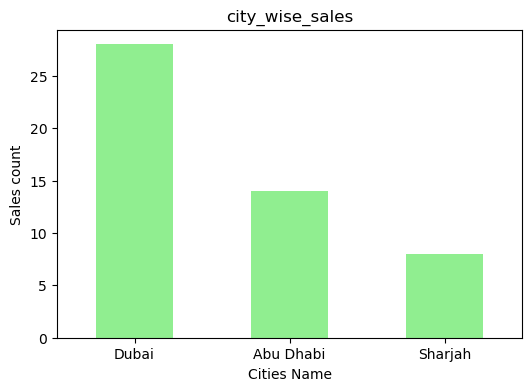

In [66]:
# Section 1 – Sales Analysis
# 📈 Monthly Sales Trend
city_wise_sales.plot(kind='bar', figsize=(6,4), color = 'lightgreen')
plt.title("city_wise_sales")
plt.xlabel("Cities Name")
plt.ylabel("Sales count")
plt.xticks(rotation = 360)
plt.show()


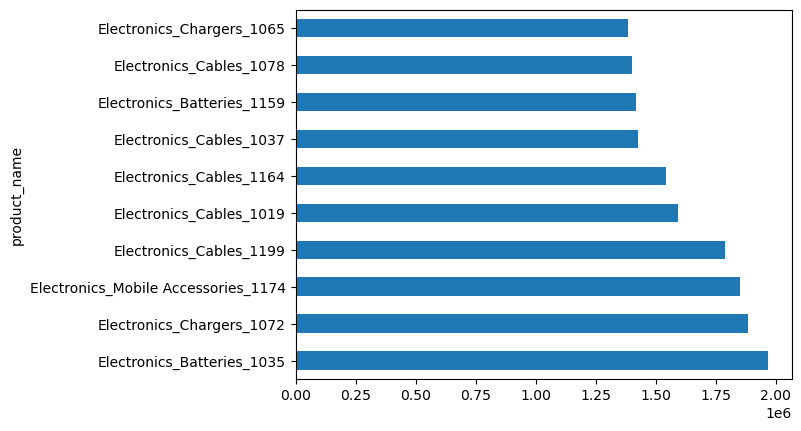

In [67]:
#  Section 2 – Product Analysis
top_10_products.plot(kind='barh')
plt.show()
